## Makemore with Multi-Layer Perceptron

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
with open("../names.txt", "r") as file:
    words = file.read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size # starts with "..."
    for ch in w + ".": # word.
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context), "-->", itos[ix])
        context = context[1:] + [ix] # remove the leftmost character from the context and append ix

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
ava
... --> a
..a --> v
.av --> a
ava --> .
isabella
... --> i
..i --> s
.is --> a
isa --> b
sab --> e
abe --> l
bel --> l
ell --> a
lla --> .
sophia
... --> s
..s --> o
.so --> p
sop --> h
oph --> i
phi --> a
hia --> .


In [6]:
X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
C = torch.randn((27, 5))
C

tensor([[ 1.1370,  1.7574,  0.9371, -1.0808,  1.0381],
        [ 0.0338, -1.5794, -2.7786, -0.4428,  0.4319],
        [ 0.5119, -0.4167,  0.1011, -0.6837,  0.1377],
        [-1.7773,  2.5438,  1.2527,  0.8452, -0.3635],
        [ 1.0000, -0.7701, -1.8699,  0.4794,  0.0500],
        [ 0.2572, -1.3376, -0.8267,  0.5228, -0.6773],
        [ 0.9877, -0.0578,  0.9499,  0.1600, -0.0885],
        [ 0.6739,  0.9582,  0.0607, -1.1813,  1.7437],
        [ 0.7261,  0.1003,  1.7004, -0.8594, -1.8023],
        [ 0.0267, -1.9557,  1.0895, -0.9223, -0.6892],
        [ 1.1325,  1.1858, -1.2233,  0.1548, -1.5784],
        [-1.1753, -1.2376, -0.4425, -0.6371,  0.0341],
        [-1.8342, -0.7722,  1.0190,  1.2992, -0.6600],
        [ 0.3186, -0.7352, -0.2496,  0.0704,  0.3525],
        [-0.2811,  1.3341,  0.3407,  1.2603,  0.3955],
        [ 0.9241,  0.0125,  1.0895,  1.6785, -1.4429],
        [ 0.1721,  0.7298,  0.7412, -0.1513, -0.2705],
        [-0.7039, -0.1029, -0.2068, -1.2080, -1.1312],
        [ 

Multiplying with one-hot encodings is the same as indexing into `C`.

In [8]:
C[5]

tensor([ 0.2572, -1.3376, -0.8267,  0.5228, -0.6773])

In [9]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.2572, -1.3376, -0.8267,  0.5228, -0.6773])

PyTorch follows NumPy's convention for 1D vectors in matmul:

    If the first argument is 1D, a 1 is prepended to its shape to make it a row vector for the purpose of matrix multiplication, and removed after.


- [27] → [1, 27]          prepend 1 (temporary row vector)
- [1, 27] @ [27, 3] → [1, 3]   standard matmul
- [1, 3] → [3]            remove the prepended dimension

In [10]:
C.shape # Maps each entry in the vocabulary to a 5-dimensional vector

torch.Size([27, 5])

In [11]:
C[X].shape # 32 is the number of examples so far, 3 is the context window, 5 is the embedding size

torch.Size([32, 3, 5])

In [12]:
X[13,2] # 13th training example, index 2

tensor(1)

In [13]:
C[X][13,2] # Embedding of 13th training example, index 2

tensor([ 0.0338, -1.5794, -2.7786, -0.4428,  0.4319])

In [14]:
C[1]

tensor([ 0.0338, -1.5794, -2.7786, -0.4428,  0.4319])

In [15]:
emb = C[X]
emb.shape

torch.Size([32, 3, 5])

In [16]:
W1 = torch.randn((15, 64)) # 15 = embedding size x batch_size
b1 = torch.randn((64))

What we want to do:

    emb @ W1 + b1

This is impossible because `emb` is 32 x 3 x 5 and W1 is 15 x 64.

In [17]:
batch_size = emb.shape[0]
(emb.reshape(batch_size, -1) @ W1 + b1).shape

torch.Size([32, 64])

In [18]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([32, 15])

In [19]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 15])

In [20]:
a = torch.arange(18)
a.shape

torch.Size([18])

In [21]:
a.view(9, 2) # This is a very efficient operation

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [22]:
a.storage(); # how it's represented in the memory

/var/folders/yb/4jbjth691bbgw6m1mnkhy9hh0000gn/T/ipykernel_6481/948452571.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage(); # how it's represented in the memory


In [23]:
torch.equal(emb.view(32, 15), torch.cat(torch.unbind(emb, 1), 1))

True

In [24]:
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)

In [25]:
h.shape

torch.Size([32, 64])

In [28]:
W2 = torch.randn((64, 27))
b2 = torch.randn(27)

In [29]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [30]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)

In [31]:
prob.shape

torch.Size([32, 27])

In [32]:
prob[13].sum()

tensor(1.)

In [34]:
# take the assigned probability of each example in the Y position
prob[torch.arange(32), Y]

tensor([1.1236e-06, 6.1368e-11, 2.5201e-07, 1.0860e-03, 4.6514e-02, 2.6114e-07,
        3.6137e-09, 3.7154e-10, 3.3689e-04, 3.5225e-12, 2.3269e-05, 9.5024e-01,
        3.1937e-03, 1.2927e-01, 5.1526e-05, 4.8705e-12, 3.0426e-14, 8.5724e-06,
        3.9553e-13, 2.9883e-03, 2.3096e-09, 2.9936e-05, 1.7370e-06, 4.8433e-05,
        9.6041e-03, 3.2832e-07, 7.8803e-04, 1.9954e-05, 8.2276e-05, 1.0253e-07,
        1.7572e-08, 2.0431e-01])

In [35]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(13.1425)

### Synthesis

In [40]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    context = [0] * block_size # starts with "..."
    for ch in w + ".": # word.
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # remove the leftmost character from the context and append ix

X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [45]:
vocab_size = 27
embedding_size = 5
hidden_size = 128

In [ ]:
g = torch.Generator().manual_seed(2122122121)
C = torch.randn((vocab_size, embedding_size), generator=g)
W1 = torch.randn((embedding_size * block_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

In [47]:
sum(p.nelement() for p in parameters) # total number of parameters

5666

In [69]:
def model(X):
    emb = C[X]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # train_size x hidden_size
    logits = h @ W2 + b2 # train_size x vocab_size
    return logits

### How to use cross entropy loss in practice

In [50]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(emb.shape[0]), Y].log().mean()
loss

tensor(19.2919)

In [52]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

loss = loss_fn(logits, Y)
loss

tensor(19.2919)

In [53]:
loss = F.cross_entropy(logits, Y)
loss

tensor(19.2919)

In [ ]:
# Important detail about cross entropy shape
# logits:  (batch_size, num_classes)  — raw scores, NOT softmax output
# targets: (batch_size,)              — integer class indices (0 to num_classes-1)

logits.shape, Y.shape

(torch.Size([228146, 27]), torch.Size([228146]))

### Training

In [85]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    context = [0] * block_size # starts with "..."
    for ch in w + ".": # word.
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # remove the leftmost character from the context and append ix

X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [95]:
g = torch.Generator().manual_seed(2122122121)
C = torch.randn((vocab_size, embedding_size), generator=g)
W1 = torch.randn((embedding_size * block_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

In [96]:
def model(X):
    emb = C[X]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # train_size x hidden_size
    logits = h @ W2 + b2 # train_size x vocab_size
    return logits

In [97]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

for p in parameters:
    p.requires_grad = True

In [98]:
lre = torch.linspace(-3, 0, 1000)
lrs= 10**lre

In [115]:
lri = []
lossi = []

for i in range(10_000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # Forward pass
    logits = model(X[ix])
    loss = loss_fn(logits, Y[ix])
    # print(loss.item())

    # Clear old gradients
    for p in parameters:
        p.grad = None
    
    # backward pass
    loss.backward()

    # update
    lr = 10 ** -0.6
    for p in parameters:
        p.data -= lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

In [116]:
# Loss on the full set
F.cross_entropy(model(X), Y)

tensor(2.2604, grad_fn=<NllLossBackward0>)

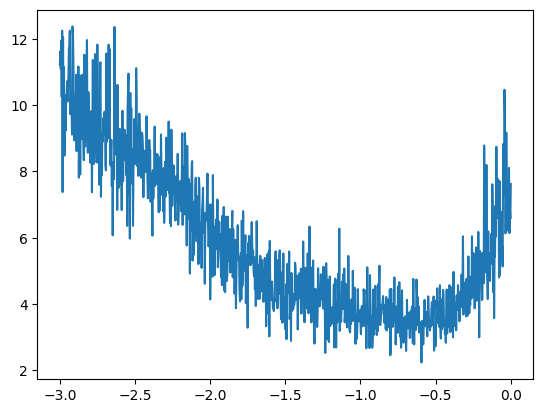

In [ ]:
plt.plot(lri, lossi)

A typical training loop

```python
model = SomeModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    for X_batch, y_batch in dataloader:

        # Forward pass
        logits = model(X_batch)          # (batch_size, num_classes)

        # Compute loss
        loss = loss_fn(logits, y_batch)  # y_batch: (batch_size,) of class indices

        # Backward pass
        optimizer.zero_grad()   # clear old gradients
        loss.backward()         # compute new gradients
        optimizer.step()        # update parameters
```

### Divide dataset

In [183]:
# build the dataset
def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        context = [0] * block_size # starts with "..."
        for ch in w + ".": # word.
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # remove the leftmost character from the context and append ix

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape, Y.shape)
    return X, Y

In [184]:
import random
random.seed(42)

random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1]) # Training
Xdev, Ydev = build_dataset(words[n1:n2]) # Validation
Xte, Yte = build_dataset(words[n2:]) # Testing

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [282]:
vocab_size = 27
embedding_size = 8
hidden_size = 256

In [283]:
g = torch.Generator().manual_seed(2122122121)
C = torch.randn((vocab_size, embedding_size), generator=g)
W1 = torch.randn((embedding_size * block_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

In [284]:
def model(X):
    emb = C[X]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # train_size x hidden_size
    logits = h @ W2 + b2 # train_size x vocab_size
    return logits

In [285]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

for p in parameters:
    p.requires_grad = True

In [288]:
step = []
tr_losses = []
dev_losses = []

for i in range(50000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    logits = model(Xtr[ix])
    loss = loss_fn(logits, Ytr[ix])
    
    # Store statistics
    if i % 100 == 0:
        with torch.no_grad():
            step.append(i)
            tr_losses.append(loss.detach().item())
            dev_losses.append(F.cross_entropy(model(Xdev), Ydev).item())


    # Clear old gradients
    for p in parameters:
        p.grad = None
    
    # backward pass
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data -= lr * p.grad


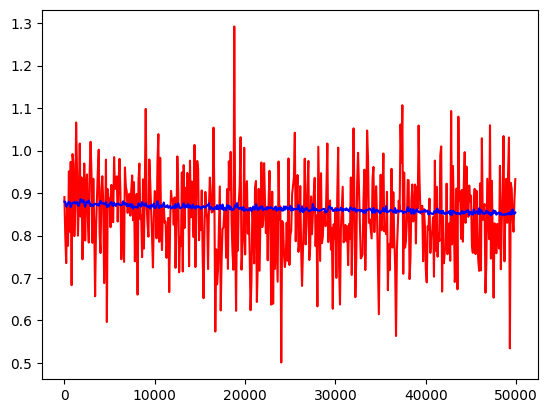

In [289]:
import numpy as np
plt.plot(step, np.log(tr_losses), 'r-', label="Training")
plt.plot(step, np.log(dev_losses), 'b-', label="Validation")
plt.show()

### Evaluation

In [291]:
# Loss on the full set
with torch.no_grad():
    print(F.cross_entropy(model(Xdev), Ydev))

tensor(2.3494)


### Inference

In [146]:
def get_starting_sequence():
    starting_sequence = [stoi["."]] * block_size
    starting_sequence = torch.tensor(starting_sequence)
    starting_sequence = starting_sequence.unsqueeze(0)
    return starting_sequence

In [147]:
starting_sequence = get_starting_sequence()
x = model(starting_sequence)
x

tensor([[-5.5572,  0.6567, -0.3031, -0.3396,  0.0219,  0.2906, -2.2698, -0.4458,
         -0.5036, -1.4045, -0.0899, -0.2270,  0.4247,  0.0709, -0.5283, -1.4471,
         -0.5854, -2.9592, -0.5983,  0.9499,  0.1304, -2.9637, -1.8675, -2.9458,
         -2.9199, -1.6813, -0.8032]], grad_fn=<AddBackward0>)

In [152]:
xi = get_starting_sequence()

logits = model(xi)

pred_i = torch.argmax(logits, dim=1)
pred_s = itos[int(pred_i.item())]

In [156]:
pred_i.unsqueeze(0)

tensor([[19]])

In [155]:
xi[:, 1:]

tensor([[0, 0]])

In [251]:
# Basic inference
with torch.no_grad():
    if isinstance(model, nn.Module):
        model.eval()

    preds = []
    xi = get_starting_sequence()
    while True:
        logits = model(xi)

        probs = torch.softmax(logits, dim=1)
        pred_i = torch.multinomial(probs, num_samples=1).squeeze(-1)
        
        pred_s = itos[int(pred_i.item())]
        preds.append(pred_s)

        if pred_i == stoi["."]:
            break

        xi = torch.cat((xi[:, 1:], pred_i.unsqueeze(0)), dim=-1)

print("".join(preds[:-1]))

meeray
